# Week 7 - Cleaning Data
This week, you will start your Machine Learning journey with cleaning data.  Data Scientists spend 80% or more of their time cleaning data and preparing data sets for Machine Learning Algorithms to create models.  This lecture will look at the Titanic dataset.  The columns in the dataset are defined below.<br>

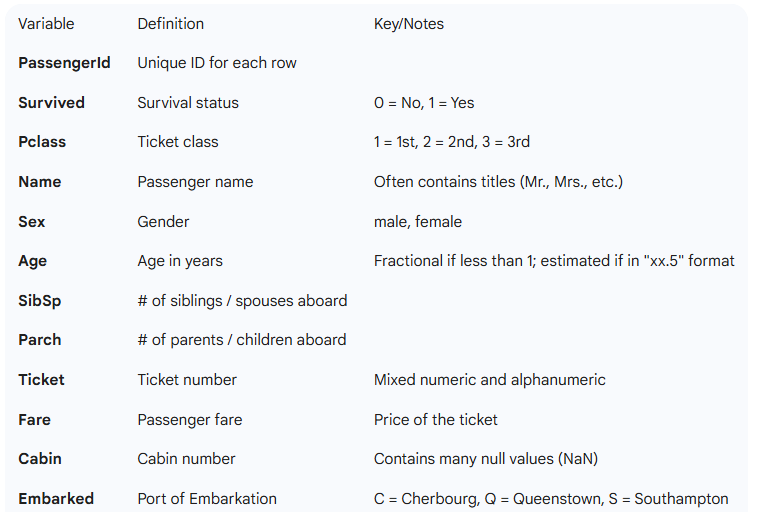


Let's start with 
1. Import the Pandas library.
2. Read in the Titanic data set.  
3. We will display 15 records of the titanic data set.


In [69]:
import pandas as pd
titanic = pd.read_csv('Titanic_clean.csv')
titanic.head(15)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",mle,22.0,1,0,A/5 21171,$7.25,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",fe-male,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",FEM,26.0,0,0,STON/O2. 3101282,7.925,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",MALE,35.0,1,0,113803,$53.1,C123,S
4,5,0,3,"Allen, Mr. William Henry",femael,35.0,0,0,373450,$8.05,NaN,S
5,6,0,3,"Moran, Mr. James",m,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,$21.075,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,$11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


# Display the Column names of a dataframe and the number of records in the dataset
```
dataframe.info()
```

In [70]:
# Display the Column names of a dataframe
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   PassengerId  891 non-null    int64 
 1   Survived     891 non-null    int64 
 2   Pclass       891 non-null    int64 
 3   Name         891 non-null    object
 4   Sex          891 non-null    object
 5   Age          714 non-null    object
 6   SibSp        891 non-null    int64 
 7   Parch        891 non-null    int64 
 8   Ticket       891 non-null    object
 9   Fare         891 non-null    object
 10  Cabin        204 non-null    object
 11  Embarked     889 non-null    object
dtypes: int64(5), object(7)
memory usage: 83.7+ KB


# Summary of info() method
The RangeIndex tell us there are 891 records.<br>
The index starts at 0 and goes to 890.<br>
The column names the number of records that are not missing.  For numerical values you can take 891 - Non-Null Count = Missing Records.<br>
The Dtype is the is int64 for an integer.  float64 is a real number.  object is a string value.<br>
We can see that the Cabin column has 891 - 204 = 687 missing records.  This column however, has information in it that can be used to improve our model.<b>


# Delete Columns that contain no information
In this titanic dataset, delete the PassengerId column, as it provides no additional information beyond the record number.
```
titantic.drop("PassengerId", axis = 1, inplace = True)
titantic.info()
```

In [71]:
titanic.drop("PassengerId", axis = 1, inplace = True)
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Survived  891 non-null    int64 
 1   Pclass    891 non-null    int64 
 2   Name      891 non-null    object
 3   Sex       891 non-null    object
 4   Age       714 non-null    object
 5   SibSp     891 non-null    int64 
 6   Parch     891 non-null    int64 
 7   Ticket    891 non-null    object
 8   Fare      891 non-null    object
 9   Cabin     204 non-null    object
 10  Embarked  889 non-null    object
dtypes: int64(4), object(7)
memory usage: 76.7+ KB


# Next we will Check for duplicate records.
It is a good idea to know how many duplicate records there are.  Especially since we have such a small dataset. <br>
- First, identify if any records are duplicates and put in put them in a new dataset call tit_dup.
- If there are not 0 records in the tit_dup dataset, then drop the 

In [72]:
tit_dup = titanic[titanic.duplicated(keep = 'first')]
if tit_dup.size != 0:
    titanic.drop_duplicates(keep = 'first', ignore_index = True, inplace = True)
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Survived  891 non-null    int64 
 1   Pclass    891 non-null    int64 
 2   Name      891 non-null    object
 3   Sex       891 non-null    object
 4   Age       714 non-null    object
 5   SibSp     891 non-null    int64 
 6   Parch     891 non-null    int64 
 7   Ticket    891 non-null    object
 8   Fare      891 non-null    object
 9   Cabin     204 non-null    object
 10  Embarked  889 non-null    object
dtypes: int64(4), object(7)
memory usage: 76.7+ KB


# Column Types
It is a good idea to determine if the data has been entered correctly.  Usually, data types of objects will show information that is interpreted as a string but is actually a numeric value.  So let's see the unique values in each of those columns.
- In Sex column find the unique values.
- In Age column find the unique values.  This column should be numeric.
- In the Ticket column find the unique values.
- In the Fare column find the unique values.  This column should be numeric.
- In Cabin column find the unique values.
- In Embarked column find the unique values.

In [73]:
titanic['Sex'].unique()

array(['mle', 'fe-male', 'FEM', 'MALE', 'femael', 'm', 'male', 'female'],
      dtype=object)

In [74]:
titanic['Ticket'].unique()

array(['A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450',
       '330877', '17463', '349909', '347742', '237736', 'PP 9549',
       '113783', 'A/5. 2151', '347082', '350406', '248706', '382652',
       '244373', '345763', '2649', '239865', '248698', '330923', '113788',
       '347077', '2631', '19950', '330959', '349216', 'PC 17601',
       'PC 17569', '335677', 'C.A. 24579', 'PC 17604', '113789', '2677',
       'A./5. 2152', '345764', '2651', '7546', '11668', '349253',
       'SC/Paris 2123', '330958', 'S.C./A.4. 23567', '370371', '14311',
       '2662', '349237', '3101295', 'A/4. 39886', 'PC 17572', '2926',
       '113509', '19947', 'C.A. 31026', '2697', 'C.A. 34651', 'CA 2144',
       '2669', '113572', '36973', '347088', 'PC 17605', '2661',
       'C.A. 29395', 'S.P. 3464', '3101281', '315151', 'C.A. 33111',
       'S.O.C. 14879', '2680', '1601', '348123', '349208', '374746',
       '248738', '364516', '345767', '345779', '330932', '113059',
       'SO/C 14885', '31012

In [75]:
titanic['Fare'].unique()

array(['$7.25', '71.2833', '7.925', '$53.1', '$8.05', '8.4583', '51.8625',
       '$21.075', '$11.1333', '30.0708', '16.7', '26.55', '8.05',
       '$31.275', '7.8542', '16.0', '$29.125', '13.0', '18.0', '7.225',
       '$26.0', '$13.0', '$8.0292', '$35.5', '21.075', '31.3875',
       '$7.225', '263.0', '$7.8792', '7.8958', '27.7208', '$146.5208',
       '$7.75', '$10.5', '$82.1708', '$52.0', '7.2292', '$18.0',
       '11.2417', '$9.475', '$21.0', '41.5792', '7.8792', '15.5',
       '$21.6792', '$17.8', '$39.6875', '7.8', '$76.7292', '26.0',
       '61.9792', '$7.2292', '27.75', '46.9', '80.0', '$83.475', '$27.9',
       '15.2458', '8.1583', '$7.925', '8.6625', '10.5', '$46.9', '$73.5',
       '14.4542', '$56.4958', '$7.65', '$29.0', '$12.475', '9.0', '$9.5',
       '$7.7875', '$47.1', '$15.85', '34.375', '$61.175', '$20.575',
       '7.25', '$34.6542', '63.3583', '23.0', '$7.8958', '77.2875',
       '8.6542', '$7.775', '$24.15', '52.0', '$9.825', '$14.4583', '21.0',
       '$247.5208'

In [76]:
titanic['Cabin'].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [77]:
titanic['Embarked'].unique()

array([' S ', ' C ', ' Q ', nan], dtype=object)

# Correct Sex column
Notice in the Sex column there are mistyped data.  So we need to correct it.
- Standardize the strings (remove spaces and lowercase everything)
- Change the every occurrence of m to male and f to female.
- 
```
df['column'] = df['column'].str.strip().str.lower().str[0].map({'m': 'male', 'f' : 'female'})
df['column'].unique()
```


In [78]:
titanic['Sex'] = titanic['Sex'].str.strip().str.lower().str[0].map({'m' : 'male', 'f' : 'female'})
titanic['Sex'].unique()

array(['male', 'female'], dtype=object)

# Correct the Fare column
In this column, the dollar sign and comma separator must be removed.  It is a string that must be converted to numeric value.
- strip the column of spaces
- Remove the $ and commas(,) 
- Convert to numeric using np.to_numeric(df['column'], errors = 'coerce')

In [79]:
titanic['Fare'] = titanic['Fare'].astype(str).str.strip()
titanic['Fare'] = titanic['Fare'].str.replace('$', "", regex = False).str.replace(',', '', regex = False)
titanic['Fare'] = pd.to_numeric(titanic['Fare'], errors = 'coerce')
titanic['Fare'] = titanic['Fare'].round(2)
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    object 
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(1), int64(4), object(6)
memory usage: 76.7+ KB


In [80]:
titanic['Age'].unique()

array(['22.0', '38.0', '26.0', '35.0', nan, '54.0', '2.0', '27.0', '14.0',
       'Unknown', '39.0', '55.0', '31.0', '34.0', '15.0', '28.0', '8.0',
       '19.0', '40.0', '66.0', '42.0', '21.0', '18.0', '3.0', '7.0',
       '49.0', '29.0', '65.0', '28.5', '5.0', '11.0', '45.0', '4.0',
       '17.0', '32.0', '16.0', '25.0', '0.83', '30.0', '33.0', '23.0',
       '24.0', '20.0', '46.0', '59.0', '71.0', '37.0', '47.0', '14.5',
       '70.5', '32.5', '12.0', '9.0', '36.5', '51.0', '55.5', '40.5',
       '44.0', '1.0', '61.0', '56.0', '50.0', '36.0', '58.0', '45.5',
       '20.5', '62.0', '41.0', '52.0', '63.0', '23.5', '0.92', '43.0',
       '60.0', '10.0', '64.0', '13.0', '48.0', '0.75', '53.0', '57.0',
       '80.0', '70.0', '24.5', '6.0', '0.67', '30.5', '0.42', '34.5',
       '74.0'], dtype=object)

In [81]:
titanic['Age'] = pd.to_numeric(titanic['Age'], errors = 'coerce')

In [82]:
titanic['Age'].unique()

array([22.  , 38.  , 26.  , 35.  ,   nan, 54.  ,  2.  , 27.  , 14.  ,
       39.  , 55.  , 31.  , 34.  , 15.  , 28.  ,  8.  , 19.  , 40.  ,
       66.  , 42.  , 21.  , 18.  ,  3.  ,  7.  , 49.  , 29.  , 65.  ,
       28.5 ,  5.  , 11.  , 45.  ,  4.  , 17.  , 32.  , 16.  , 25.  ,
        0.83, 30.  , 33.  , 23.  , 24.  , 20.  , 46.  , 59.  , 71.  ,
       37.  , 47.  , 14.5 , 70.5 , 32.5 , 12.  ,  9.  , 36.5 , 51.  ,
       55.5 , 40.5 , 44.  ,  1.  , 61.  , 56.  , 50.  , 36.  , 58.  ,
       45.5 , 20.5 , 62.  , 41.  , 52.  , 63.  , 23.5 ,  0.92, 43.  ,
       60.  , 10.  , 64.  , 13.  , 48.  ,  0.75, 53.  , 57.  , 80.  ,
       70.  , 24.5 ,  6.  ,  0.67, 30.5 ,  0.42, 34.5 , 74.  ])

In [83]:
titanic.head(20)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.28,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.92,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",male,35.0,1,0,113803,53.10,C123,S
4,0,3,"Allen, Mr. William Henry",female,35.0,0,0,373450,8.05,NaN,S
5,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.46,NaN,Q
6,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.86,E46,S
7,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.08,NaN,S
8,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.13,NaN,S
9,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.07,NaN,C


# Looking at the Numeric data 
To review the numeric data, run the describe().T method for the titanic dataframe
```
df.describe().T
```

In [84]:
titanic.describe().T

,count,mean,std,min,25%,50%,75%,max
Survived,891.0,0.383838,0.486592,0.00,0.00,0.00,1.0,1.00
Pclass,891.0,2.308642,0.836071,1.00,2.00,3.00,3.0,3.00
Age,711.0,29.709100,14.481708,0.42,20.75,28.00,38.0,80.00
SibSp,891.0,0.523008,1.102743,0.00,0.00,0.00,1.0,8.00
Parch,891.0,0.381594,0.806057,0.00,0.00,0.00,0.0,6.00
Fare,891.0,32.204366,49.693414,0.00,7.91,14.45,31.0,512.33


In [ ]:
# Save the cleaned file to csv file
After cleaning your data set you need to save the file to use next week to do featuring engineering of the columns.
- Save the file to Titanic_eda.csv without index.

In [85]:
# Save the cleaned dataset
titanic.to_csv("Titanic_eda.csv", index = False)